
# Revisiting my 2021 Master's Thesis in Python
## Parte 3 — How I would approach it in 2026

Dopo aver ricostruito il workflow originale, questa parte **abbandona volutamente il protocollo 2021**.

La domanda non è più:

> *Riesco a ottenere gli stessi numeri della tesi?*

ma:

> *Se affrontassi oggi lo stesso problema, quali scelte farei diversamente e quali conclusioni cambierebbero?*

### Principali modifiche

- split prima di qualsiasi preprocessing;
- holdout **temporale**, per simulare sessioni future;
- preprocessing fit esclusivamente sul training set;
- cross-validation per scegliere gli iperparametri;
- gestione dello sbilanciamento all'interno della pipeline;
- **PR-AUC** oltre alla ROC-AUC;
- threshold tuning senza utilizzare il test set;
- confronto tra:
  - **session-complete features**;
  - **early-session features**.

L'ultimo confronto è il più importante: `hits` e `pageviews` descrivono l'intera attività svolta durante la sessione. Sono predittori molto forti, ma non sarebbero completamente disponibili se l'obiettivo fosse prevedere l'acquisto **prima della conclusione della sessione**.


In [1]:

from pathlib import Path
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, train_test_split,
    TunedThresholdClassifierCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = Path("Data_Frame_Gstore_sample.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/Data_Frame_Gstore_sample.csv")


## 1. Preparazione del dataset

In [2]:

def clean_gstore(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    object_cols = df.select_dtypes(include=["object", "string"]).columns
    for col in object_cols:
        s = df[col].astype("string")
        df[col] = s.mask(s.eq("not available in demo dataset"))

    df = df.dropna(axis=1, how="all")
    df["transactionRevenue"] = pd.to_numeric(
        df["transactionRevenue"], errors="coerce"
    ).fillna(0)

    drop_cols = [
        "adwordsClickInfo.gclId", "adwordsClickInfo.slot",
        "adwordsClickInfo.page", "adwordsClickInfo.adNetworkType",
        "adwordsClickInfo.isVideoAd", "adContent", "keyword",
        "referralPath", "networkDomain", "campaign",
        "socialEngagementType", "city", "metro", "region"
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    for col, value in [("newVisits", 0), ("bounces", 0), ("pageviews", 1)]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(value)

    source = df["source"].astype("string")
    df["source"] = np.select(
        [
            source.str.contains("google", case=False, na=False),
            source.str.contains("youtube", case=False, na=False),
            source.str.contains("direct", case=False, na=False)
        ],
        ["Google", "Youtube", "Direct"],
        default="Altri"
    )

    for col in ["continent", "subContinent", "country"]:
        mask = df[col].astype("string").str.contains(
            "not set", case=False, na=False
        )
        df.loc[mask, col] = "Sconosciuto"

    os_keep = ["Android", "Chrome OS", "iOS", "Linux", "Macintosh", "Windows"]
    df["operatingSystem"] = df["operatingSystem"].where(
        df["operatingSystem"].isin(os_keep), "Altri OS"
    )

    browser_keep = ["Chrome", "Edge", "Firefox", "Internet Explorer", "Safari"]
    df["browser"] = df["browser"].where(
        df["browser"].isin(browser_keep), "Altri"
    )

    df["date"] = pd.to_datetime(
        df["date"].astype(str), format="%Y%m%d", errors="coerce"
    )
    df["visitStartTime"] = pd.to_datetime(
        pd.to_numeric(df["visitStartTime"], errors="coerce"),
        unit="s", utc=True
    )

    for col in ["visitNumber", "hits", "pageviews", "newVisits", "transactionRevenue"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["channelGrouping"] = df["channelGrouping"].replace("(Other)", "Altri")

    rare_subcontinents = [
        "Caribbean", "Central Asia", "Eastern Africa", "Melanesia",
        "Micronesian Region", "Middle Africa", "Northern Africa",
        "Polynesia", "Southern Africa", "Western Africa",
        "Unknown", "Sconosciuto"
    ]
    df.loc[df["subContinent"].isin(rare_subcontinents), "subContinent"] = "Altri"

    df["dow"] = ((df["visitStartTime"].dt.dayofweek + 1) % 7) + 1
    df["month"] = df["date"].dt.month
    df["hours"] = df["visitStartTime"].dt.hour
    df["purchase"] = (df["transactionRevenue"] > 0).astype(int)
    df["newVisits"] = df["newVisits"].fillna(0).astype(int)

    return df


raw = pd.read_csv(DATA_PATH, encoding="cp1252", low_memory=False)
df = clean_gstore(raw)

model_df = df[
    [
        "channelGrouping", "visitNumber", "visitStartTime",
        "browser", "operatingSystem", "continent", "subContinent",
        "country", "hits", "pageviews", "newVisits", "source",
        "dow", "month", "hours", "purchase"
    ]
].copy()

print(f"Osservazioni: {len(model_df):,}")
print(f"Acquisti: {model_df['purchase'].sum():,}")
print(f"Purchase rate: {model_df['purchase'].mean():.2%}")


Osservazioni: 25,000
Acquisti: 323
Purchase rate: 1.29%



## 2. Holdout temporale

Nel workflow 2021 la fase predittiva utilizzava uno split casuale.

Qui ordiniamo invece le sessioni per `visitStartTime`:

- prime 20.000 sessioni → training;
- ultime 5.000 → test.

È un test più vicino alla domanda reale:

> *un modello addestrato sul passato riesce a generalizzare a sessioni future?*


In [3]:

ordered = model_df.sort_values("visitStartTime").reset_index(drop=True)

train_df = ordered.iloc[:20000].copy()
test_df = ordered.iloc[20000:].copy()

split_summary = pd.DataFrame(
    {
        "N": [len(train_df), len(test_df)],
        "Acquisti": [
            train_df["purchase"].sum(),
            test_df["purchase"].sum()
        ],
        "Purchase rate": [
            train_df["purchase"].mean(),
            test_df["purchase"].mean()
        ],
        "Data iniziale": [
            train_df["visitStartTime"].min(),
            test_df["visitStartTime"].min()
        ],
        "Data finale": [
            train_df["visitStartTime"].max(),
            test_df["visitStartTime"].max()
        ]
    },
    index=["Train", "Temporal holdout"]
)

display(split_summary)


,N,Acquisti,Purchase rate,Data iniziale,Data finale
Train,20000,246,0.0123,2016-08-01 07:24:51+00:00,2017-05-08 23:57:39+00:00
Temporal holdout,5000,77,0.0154,2017-05-09 00:16:38+00:00,2017-08-02 05:39:51+00:00



### Nota

Il temporal holdout contiene **77 acquisti su 5.000 sessioni**, quindi una prevalence di circa **1,54%**.

Questa percentuale sarà anche la baseline intuitiva della **Precision-Recall curve**: una PR-AUC vicina all'1,5% avrebbe poco valore discriminante.



## 3. Accuracy trap: baseline senza Machine Learning

Prima dei modelli, ripetiamo in modo esplicito una delle conclusioni più corrette della tesi: con classi così sbilanciate, l'accuracy può essere molto alta anche per un classificatore inutile.


In [4]:

dummy = DummyClassifier(strategy="most_frequent")
X_dummy_train = np.zeros((len(train_df), 1))
X_dummy_test = np.zeros((len(test_df), 1))

dummy.fit(X_dummy_train, train_df["purchase"])
dummy_pred = dummy.predict(X_dummy_test)

dummy_accuracy = accuracy_score(test_df["purchase"], dummy_pred)
dummy_recall = recall_score(test_df["purchase"], dummy_pred, zero_division=0)

print(f"Accuracy prevedendo sempre 'non acquisto': {dummy_accuracy:.2%}")
print(f"Sensitivity / Recall: {dummy_recall:.2%}")


Accuracy prevedendo sempre 'non acquisto': 98.46%
Sensitivity / Recall: 0.00%



Un modello che non identifica **nessun acquisto** supera comunque il **98% di accuracy**. È il motivo per cui nella revisione 2026 la metrica principale per il tuning sarà **Average Precision / PR-AUC**.



## 4. Due definizioni diverse del problema predittivo

### A — Session-complete

Usa:

- `visitNumber`
- `hits`
- `pageviews`
- `newVisits`
- giorno
- mese
- ora

È vicino al problema affrontato nella tesi: classificare una sessione utilizzando tutte le informazioni raccolte durante la sessione.

### B — Early-session

Esclude:

- `hits`
- `pageviews`

Rimangono soltanto informazioni disponibili molto prima della conclusione della sessione.

Questo cambia sostanzialmente il significato del modello.


In [5]:

numeric_complete = [
    "visitNumber", "hits", "pageviews",
    "newVisits", "dow", "month", "hours"
]
numeric_early = [
    "visitNumber", "newVisits", "dow", "month", "hours"
]

categorical_early = [
    "channelGrouping", "browser", "operatingSystem",
    "continent", "subContinent", "country", "source"
]

y_train = train_df["purchase"].to_numpy()
y_test = test_df["purchase"].to_numpy()

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


## 5. Metriche

In [6]:

def evaluate_binary(y_true, y_pred, score):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return {
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, score),
        "PR_AUC": average_precision_score(y_true, score),
        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn)
    }



# 6. Numeric models — preprocessing leakage-free

Ora lo `StandardScaler` è **dentro la pipeline**: durante ogni fold di cross-validation viene stimato esclusivamente sui dati di training del fold.

### Logistic Regression

- `class_weight="balanced"`
- tuning di `C`
- selezione tramite PR-AUC

### LDA

- prior bilanciati 50/50
- confronto tra solver e shrinkage

### SVM

- `class_weight="balanced"`
- tuning di `C` e `gamma`
- per limitare il costo computazionale, il tuning SVM viene svolto su un sottoinsieme stratificato di 6.000 osservazioni del training; il modello selezionato viene poi riaddestrato su tutte le 20.000 sessioni.


In [7]:

numeric_rows = []
numeric_scores = {}
best_numeric_logistic = {}

feature_sets = {
    "Session-complete": numeric_complete,
    "Early-session": numeric_early
}

for feature_name, columns in feature_sets.items():
    X_train = train_df[columns].to_numpy(float)
    X_test = test_df[columns].to_numpy(float)

    # Logistic
    logistic_pipe = Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            solver="lbfgs",
            max_iter=3000
        ))
    ])

    logistic_grid = GridSearchCV(
        logistic_pipe,
        {"clf__C": [0.01, 0.1, 1, 10]},
        scoring="average_precision",
        cv=cv,
        n_jobs=1
    )
    logistic_grid.fit(X_train, y_train)

    logistic_score = logistic_grid.predict_proba(X_test)[:, 1]
    logistic_pred = logistic_grid.predict(X_test)

    numeric_rows.append({
        "Feature set": feature_name,
        "Model": "Logistic balanced",
        "Best params": str(logistic_grid.best_params_),
        **evaluate_binary(y_test, logistic_pred, logistic_score)
    })
    numeric_scores[(feature_name, "Logistic balanced")] = logistic_score
    best_numeric_logistic[feature_name] = logistic_grid.best_estimator_

    # LDA
    lda_pipe = Pipeline([
        ("scale", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis(
            priors=[0.5, 0.5]
        ))
    ])

    lda_grid = GridSearchCV(
        lda_pipe,
        [
            {
                "clf__solver": ["svd"],
                "clf__shrinkage": [None]
            },
            {
                "clf__solver": ["lsqr"],
                "clf__shrinkage": [None, "auto"]
            }
        ],
        scoring="average_precision",
        cv=cv,
        n_jobs=1
    )
    lda_grid.fit(X_train, y_train)

    lda_score = lda_grid.predict_proba(X_test)[:, 1]
    lda_pred = lda_grid.predict(X_test)

    numeric_rows.append({
        "Feature set": feature_name,
        "Model": "LDA balanced prior",
        "Best params": str(lda_grid.best_params_),
        **evaluate_binary(y_test, lda_pred, lda_score)
    })
    numeric_scores[(feature_name, "LDA balanced prior")] = lda_score

    # SVM: tune on stratified 6k subset, then fit all training data
    all_ids = np.arange(len(X_train))
    tune_ids, _ = train_test_split(
        all_ids,
        train_size=6000,
        stratify=y_train,
        random_state=42
    )

    svm_pipe = Pipeline([
        ("scale", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            class_weight="balanced",
            cache_size=1000
        ))
    ])

    svm_grid = GridSearchCV(
        svm_pipe,
        {
            "clf__C": [1, 10],
            "clf__gamma": ["scale", 0.01]
        },
        scoring="average_precision",
        cv=3,
        n_jobs=1
    )
    svm_grid.fit(X_train[tune_ids], y_train[tune_ids])

    svm_best = svm_grid.best_estimator_
    svm_best.fit(X_train, y_train)

    svm_score = svm_best.decision_function(X_test)
    svm_pred = svm_best.predict(X_test)

    numeric_rows.append({
        "Feature set": feature_name,
        "Model": "SVM balanced",
        "Best params": str(svm_grid.best_params_),
        **evaluate_binary(y_test, svm_pred, svm_score)
    })
    numeric_scores[(feature_name, "SVM balanced")] = svm_score


numeric_results = pd.DataFrame(numeric_rows)

display(
    numeric_results[
        [
            "Feature set", "Model", "Sensitivity", "Specificity",
            "Precision", "F1", "Accuracy", "ROC_AUC", "PR_AUC",
            "Best params"
        ]
    ]
)


,Feature set,Model,Sensitivity,Specificity,Precision,F1,Accuracy,ROC_AUC,PR_AUC,Best params
0,Session-complete,Logistic balanced,0.9481,0.9496,0.2274,0.3668,0.9496,0.9837,0.4035,{'clf__C': 10}
1,Session-complete,LDA balanced prior,0.8442,0.9478,0.2019,0.3258,0.9462,0.9623,0.3700,"{'clf__shrinkage': None, 'clf__solver': 'lsqr'}"
2,Session-complete,SVM balanced,0.9610,0.9439,0.2114,0.3466,0.9442,0.9796,0.3728,"{'clf__C': 10, 'clf__gamma': 0.01}"
3,Early-session,Logistic balanced,0.6364,0.7573,0.0394,0.0742,0.7554,0.7174,0.0362,{'clf__C': 0.01}
4,Early-session,LDA balanced prior,0.6364,0.7573,0.0394,0.0742,0.7554,0.7303,0.0360,"{'clf__shrinkage': 'auto', 'clf__solver': 'lsqr'}"
5,Early-session,SVM balanced,0.6234,0.7757,0.0417,0.0781,0.7734,0.7087,0.0392,"{'clf__C': 1, 'clf__gamma': 'scale'}"



## 7. Il risultato più importante: cosa succede senza `hits` e `pageviews`?

Visualizziamo direttamente ROC-AUC e PR-AUC per i tre modelli.


In [8]:

auc_comparison = numeric_results.pivot(
    index="Model",
    columns="Feature set",
    values=["ROC_AUC", "PR_AUC"]
)

display(auc_comparison)


ROC_AUC                         PR_AUC  \
Feature set        Early-session Session-complete Early-session   
Model                                                             
LDA balanced prior        0.7303           0.9623        0.0360   
Logistic balanced         0.7174           0.9837        0.0362   
SVM balanced              0.7087           0.9796        0.0392   

                                     
Feature set        Session-complete  
Model                                
LDA balanced prior           0.3700  
Logistic balanced            0.4035  
SVM balanced                 0.3728

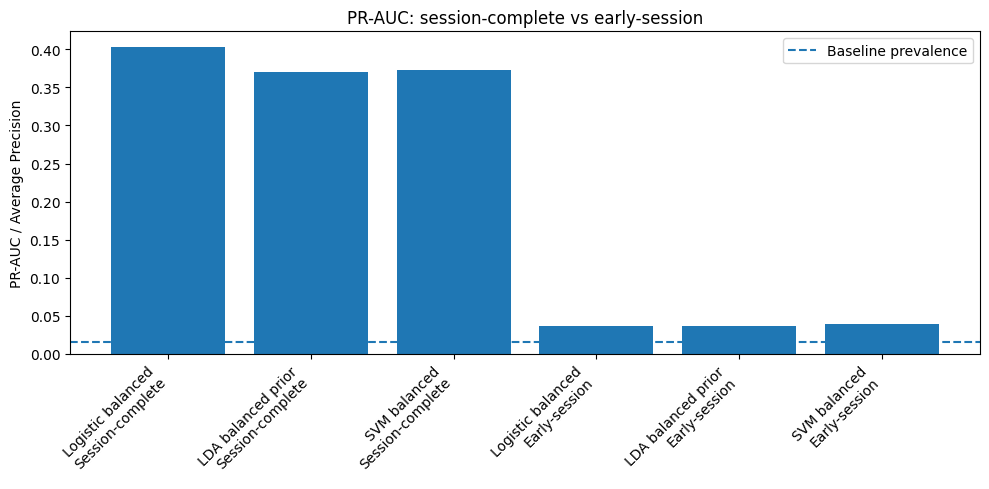

In [9]:

plot_data = numeric_results.copy()
labels = [
    f"{r['Model']}\n{r['Feature set']}"
    for _, r in plot_data.iterrows()
]

plt.figure(figsize=(10, 5))
plt.bar(labels, plot_data["PR_AUC"])
plt.axhline(
    y=test_df["purchase"].mean(),
    linestyle="--",
    label="Baseline prevalence"
)
plt.ylabel("PR-AUC / Average Precision")
plt.title("PR-AUC: session-complete vs early-session")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()



### Evidenza

Con `hits` e `pageviews`, Logistic Regression e SVM mantengono una **ROC-AUC prossima a 0,98** e una PR-AUC nell'ordine di **0,37–0,40**.

Eliminandole, la ROC-AUC scende intorno a **0,72–0,74** e la PR-AUC a circa **0,04**.

Quindi una quota sostanziale della capacità discriminante osservata nella tesi deriva da informazioni che descrivono **quanto l'utente ha già interagito con il sito durante la sessione**.

Questo non rende sbagliato il modello originale: significa però che il problema è più vicino alla **classificazione di una sessione completa** che alla previsione anticipata di un acquisto.



# 8. Le variabili qualitative aiutano l'early prediction?

La tesi aveva già mostrato che eliminare le variabili qualitative peggiorava leggermente le performance.

Ora verifichiamo una domanda più utile: se non possiamo usare `hits` e `pageviews`, informazioni come **source, channel, browser, OS e geografia** riescono a recuperare parte della capacità predittiva?

Utilizziamo:

- one-hot encoding;
- categorie rare raggruppate automaticamente (`min_frequency=10`);
- unknown category gestite senza errore;
- Logistic Regression con class weighting;
- tuning di `C` tramite PR-AUC.


In [10]:

mixed_rows = []
mixed_scores = {}
best_mixed_models = {}

mixed_feature_sets = {
    "Session-complete mixed": numeric_complete,
    "Early-session mixed": numeric_early
}

for feature_name, numeric_columns in mixed_feature_sets.items():
    columns = categorical_early + numeric_columns

    X_train = train_df[columns].copy()
    X_test = test_df[columns].copy()

    preprocessor = ColumnTransformer([
        (
            "cat",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=10,
                drop="first"
            ),
            categorical_early
        ),
        (
            "num",
            StandardScaler(),
            numeric_columns
        )
    ])

    pipeline = Pipeline([
        ("pre", preprocessor),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                max_iter=3000
            )
        )
    ])

    search = GridSearchCV(
        pipeline,
        {"clf__C": [0.01, 0.1, 1, 10]},
        scoring="average_precision",
        cv=cv,
        n_jobs=1
    )

    search.fit(X_train, y_train)

    score = search.predict_proba(X_test)[:, 1]
    pred = search.predict(X_test)

    mixed_rows.append({
        "Feature set": feature_name,
        "Model": "Logistic mixed balanced",
        "Best params": str(search.best_params_),
        **evaluate_binary(y_test, pred, score)
    })

    mixed_scores[feature_name] = score
    best_mixed_models[feature_name] = search.best_estimator_


mixed_results = pd.DataFrame(mixed_rows)

display(
    mixed_results[
        [
            "Feature set", "Sensitivity", "Specificity",
            "Precision", "F1", "Accuracy",
            "ROC_AUC", "PR_AUC", "Best params"
        ]
    ]
)


,Feature set,Sensitivity,Specificity,Precision,F1,Accuracy,ROC_AUC,PR_AUC,Best params
0,Session-complete mixed,0.9481,0.9602,0.2714,0.4220,0.9600,0.9817,0.4515,{'clf__C': 1}
1,Early-session mixed,0.8701,0.7038,0.0439,0.0836,0.7064,0.8747,0.1671,{'clf__C': 0.01}



### Seconda evidenza

Le variabili qualitative cambiano parecchio il quadro dell'**early prediction**:

- la ROC-AUC sale sensibilmente;
- la PR-AUC passa da circa **0,04** a circa **0,17**.

Quindi source, channel, device e geografia contengono informazione utile già nelle prime fasi della sessione.

Resta però una distanza molto ampia rispetto al modello che conosce anche `hits` e `pageviews`: il problema anticipato è realmente più difficile.


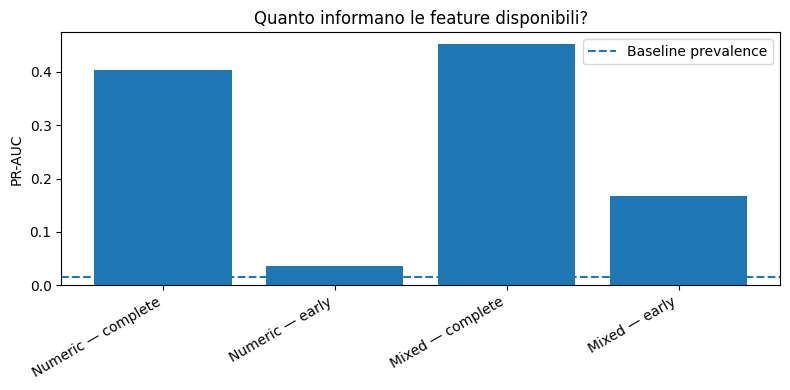

In [11]:

combined_ap = pd.DataFrame([
    {
        "Scenario": "Numeric — complete",
        "PR_AUC": numeric_results.query(
            "`Feature set` == 'Session-complete' and Model == 'Logistic balanced'"
        )["PR_AUC"].iloc[0]
    },
    {
        "Scenario": "Numeric — early",
        "PR_AUC": numeric_results.query(
            "`Feature set` == 'Early-session' and Model == 'Logistic balanced'"
        )["PR_AUC"].iloc[0]
    },
    {
        "Scenario": "Mixed — complete",
        "PR_AUC": mixed_results.query(
            "`Feature set` == 'Session-complete mixed'"
        )["PR_AUC"].iloc[0]
    },
    {
        "Scenario": "Mixed — early",
        "PR_AUC": mixed_results.query(
            "`Feature set` == 'Early-session mixed'"
        )["PR_AUC"].iloc[0]
    }
])

plt.figure(figsize=(8, 4))
plt.bar(combined_ap["Scenario"], combined_ap["PR_AUC"])
plt.axhline(
    test_df["purchase"].mean(),
    linestyle="--",
    label="Baseline prevalence"
)
plt.ylabel("PR-AUC")
plt.title("Quanto informano le feature disponibili?")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()



# 9. SMOTE dentro la cross-validation

Nel 2021 SMOTE veniva applicato al training set dopo uno scaling effettuato sull'intero dataset.

Nel workflow aggiornato:

`fold training → scaling → SMOTE → model`

Il validation fold non viene utilizzato né per lo scaling né per generare osservazioni sintetiche.

Inoltre non imponiamo automaticamente un rapporto 50/50: la quota di oversampling viene scelta tramite cross-validation.


In [12]:

smote_rows = []

for feature_name, columns in feature_sets.items():
    X_train = train_df[columns].to_numpy(float)
    X_test = test_df[columns].to_numpy(float)

    pipe = ImbPipeline([
        ("scale", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        (
            "clf",
            LogisticRegression(
                solver="lbfgs",
                max_iter=3000
            )
        )
    ])

    search = GridSearchCV(
        pipe,
        {
            "smote__sampling_strategy": [0.25, 0.5, 1.0],
            "clf__C": [0.1, 1, 10]
        },
        scoring="average_precision",
        cv=cv,
        n_jobs=1
    )

    search.fit(X_train, y_train)

    score = search.predict_proba(X_test)[:, 1]
    pred = search.predict(X_test)

    smote_rows.append({
        "Feature set": feature_name,
        "Model": "Logistic + SMOTE in CV",
        "Best params": str(search.best_params_),
        **evaluate_binary(y_test, pred, score)
    })


smote_results = pd.DataFrame(smote_rows)

display(
    smote_results[
        [
            "Feature set", "Sensitivity", "Specificity",
            "Precision", "F1", "Accuracy",
            "ROC_AUC", "PR_AUC", "Best params"
        ]
    ]
)


,Feature set,Sensitivity,Specificity,Precision,F1,Accuracy,ROC_AUC,PR_AUC,Best params
0,Session-complete,0.8052,0.9754,0.3388,0.4769,0.9728,0.9821,0.3865,"{'clf__C': 1, 'smote__sampling_strategy': 0.25}"
1,Early-session,0.0000,1.0000,0.0000,0.0000,0.9846,0.7229,0.0371,"{'clf__C': 0.1, 'smote__sampling_strategy': 0.25}"



### Nota

Nel caso session-complete la cross-validation seleziona un oversampling **parziale**, non il bilanciamento 50/50.

È un promemoria importante: *più balancing* non significa automaticamente *modello migliore*. La quantità di oversampling è a sua volta un iperparametro.



# 10. Threshold tuning

Il threshold `0.5` non è una legge naturale.

In un problema raro, la soglia dovrebbe dipendere dal costo relativo di:

- falso positivo;
- falso negativo.

Per mostrare l'effetto senza utilizzare il test set, scegliamo il threshold tramite **3-fold cross-validation sul training**, massimizzando F1.

Applichiamo questa logica alla Logistic Regression con feature miste.


In [13]:

threshold_rows = []
tuned_models = {}

for feature_name, numeric_columns in mixed_feature_sets.items():
    columns = categorical_early + numeric_columns

    X_train = train_df[columns].copy()
    X_test = test_df[columns].copy()

    base_estimator = best_mixed_models[feature_name]

    tuned = TunedThresholdClassifierCV(
        estimator=base_estimator,
        scoring="f1",
        cv=3,
        refit=True
    )

    tuned.fit(X_train, y_train)

    score = tuned.predict_proba(X_test)[:, 1]
    pred = tuned.predict(X_test)

    threshold_rows.append({
        "Feature set": feature_name,
        "Model": "Logistic mixed + threshold CV",
        "Best threshold": tuned.best_threshold_,
        **evaluate_binary(y_test, pred, score)
    })

    tuned_models[feature_name] = tuned


threshold_results = pd.DataFrame(threshold_rows)

display(
    threshold_results[
        [
            "Feature set", "Best threshold",
            "Sensitivity", "Specificity",
            "Precision", "F1", "Accuracy",
            "ROC_AUC", "PR_AUC"
        ]
    ]
)


,Feature set,Best threshold,Sensitivity,Specificity,Precision,F1,Accuracy,ROC_AUC,PR_AUC
0,Session-complete mixed,0.9697,0.5195,0.9907,0.4651,0.4908,0.9834,0.9817,0.4515
1,Early-session mixed,0.8452,0.4156,0.9368,0.0933,0.1524,0.9288,0.8747,0.1671



### Terza evidenza

Per il modello session-complete la soglia selezionata è molto più alta di `0.5`: la sensitivity scende, ma diminuiscono drasticamente anche i falsi positivi e **F1 migliora**.

Per l'early-session model il tuning del threshold migliora precision e F1, ma non può compensare una separazione delle classi molto più debole.

La soglia modifica il punto operativo; **non modifica ROC-AUC e PR-AUC**, perché queste descrivono il ranking complessivo degli score.



# 11. ROC vs Precision-Recall

Con una classe positiva dell'1–2%, una ROC-AUC elevata può apparire molto rassicurante.

La Precision-Recall curve rende più evidente quanto sia difficile ottenere contemporaneamente:

- alta capacità di intercettare gli acquisti;
- pochi falsi positivi.


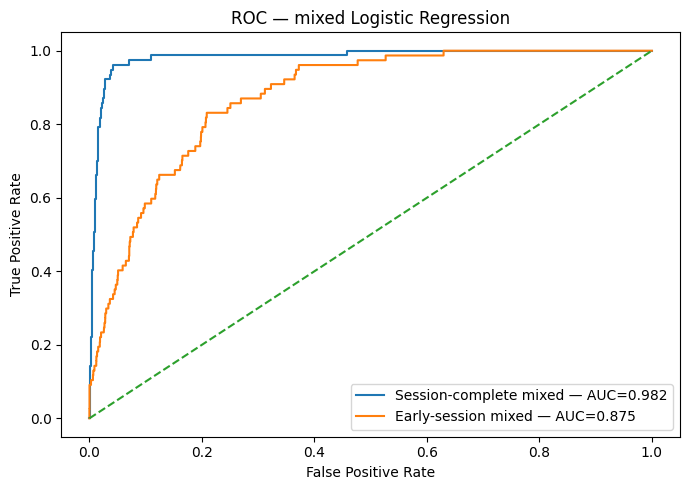

In [14]:

plt.figure(figsize=(7, 5))

for feature_name in [
    "Session-complete mixed",
    "Early-session mixed"
]:
    score = mixed_scores[feature_name]
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    plt.plot(
        fpr, tpr,
        label=f"{feature_name} — AUC={auc:.3f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — mixed Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()


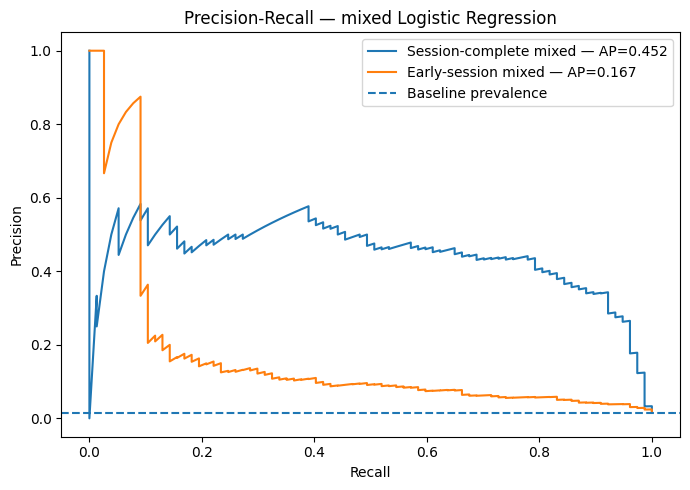

In [15]:

plt.figure(figsize=(7, 5))

for feature_name in [
    "Session-complete mixed",
    "Early-session mixed"
]:
    score = mixed_scores[feature_name]
    precision, recall, _ = precision_recall_curve(
        y_test, score
    )
    ap = average_precision_score(y_test, score)
    plt.plot(
        recall, precision,
        label=f"{feature_name} — AP={ap:.3f}"
    )

plt.axhline(
    y=test_df["purchase"].mean(),
    linestyle="--",
    label="Baseline prevalence"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall — mixed Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()



# 12. Quali early-session feature utilizza la Logistic Regression?

Per mantenere un minimo di interpretabilità, osserviamo i coefficienti del modello `Early-session mixed`.

Questa lettura è **descrittiva, non causale**: un coefficiente non dimostra che una variabile provochi l'acquisto.


In [16]:

early_model = best_mixed_models["Early-session mixed"]
pre = early_model.named_steps["pre"]
clf = early_model.named_steps["clf"]

feature_names = pre.get_feature_names_out()
coefs = clf.coef_.ravel()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs,
    "AbsCoefficient": np.abs(coefs)
}).sort_values("AbsCoefficient", ascending=False)

display(coef_df.head(20))


,Feature,Coefficient,AbsCoefficient
12,cat__operatingSystem_Android,-1.1164,1.1164
20,cat__continent_Europe,-0.9448,0.9448
5,cat__channelGrouping_Social,-0.8959,0.8959
19,cat__continent_Asia,-0.7342,0.7342
17,cat__operatingSystem_iOS,-0.6709,0.6709
121,cat__country_United States,0.6470,0.6470
128,cat__source_Youtube,-0.6291,0.6291
15,cat__operatingSystem_Macintosh,0.5535,0.5535
123,cat__country_Venezuela,0.5232,0.5232
27,cat__subContinent_Northern America,0.5169,0.5169


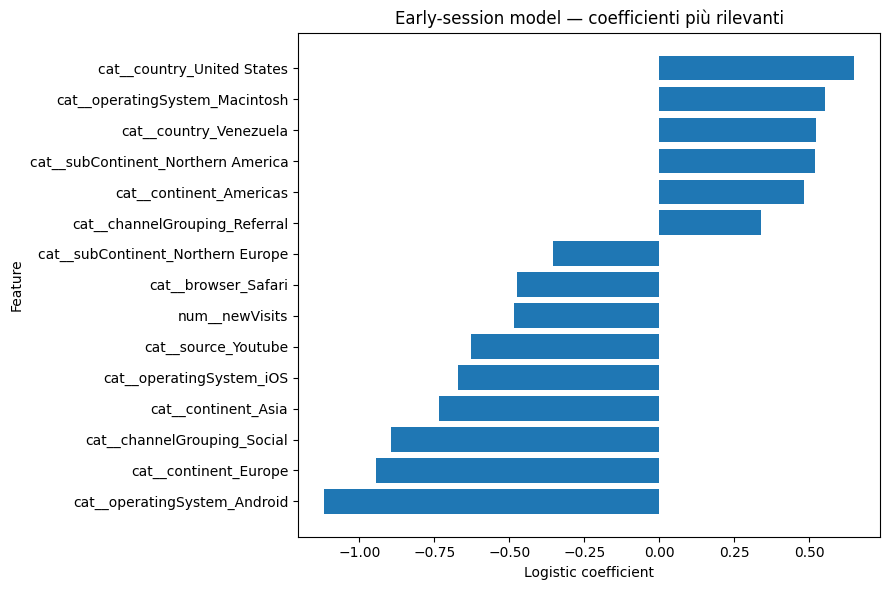

In [17]:

top_coef = coef_df.head(15).sort_values("Coefficient")

plt.figure(figsize=(9, 6))
plt.barh(top_coef["Feature"], top_coef["Coefficient"])
plt.xlabel("Logistic coefficient")
plt.ylabel("Feature")
plt.title("Early-session model — coefficienti più rilevanti")
plt.tight_layout()
plt.show()



# 13. 2021 vs 2026 — cosa è cambiato davvero?


In [18]:

methodology_comparison = pd.DataFrame(
    [
        ["Split", "Random 80/20", "Temporal holdout 80/20"],
        ["Scaling", "Prima dello split", "Fit solo sul training/fold"],
        ["Balancing", "Training pre-generato", "Dentro la CV pipeline"],
        ["SMOTE ratio", "Fisso", "Tuned"],
        ["SVM parameters", "C=10, gamma=0.01", "Cross-validation"],
        ["Primary evaluation", "ROC + confusion metrics", "PR-AUC + ROC + confusion metrics"],
        ["Threshold", "Principalmente 0.5", "Tuned sul training"],
        ["Feature timing", "Session-complete", "Complete vs early-session"],
        ["Categorical handling", "R factors", "One-hot + rare/unknown handling"],
        ["Reproducibility", "Script sequenziali", "Executable notebook + pipeline"]
    ],
    columns=["Aspect", "2021 thesis", "2026 revision"]
)

display(methodology_comparison)


,Aspect,2021 thesis,2026 revision
0,Split,Random 80/20,Temporal holdout 80/20
1,Scaling,Prima dello split,Fit solo sul training/fold
2,Balancing,Training pre-generato,Dentro la CV pipeline
3,SMOTE ratio,Fisso,Tuned
4,SVM parameters,"C=10, gamma=0.01",Cross-validation
5,Primary evaluation,ROC + confusion metrics,PR-AUC + ROC + confusion metrics
6,Threshold,Principalmente 0.5,Tuned sul training
7,Feature timing,Session-complete,Complete vs early-session
8,Categorical handling,R factors,One-hot + rare/unknown handling
9,Reproducibility,Script sequenziali,Executable notebook + pipeline



# 14. Main findings

## 1. La conclusione sull'accuracy era corretta

Il dataset è così sbilanciato che un classificatore che non identifica un singolo acquisto supera comunque il 98% di accuracy.

## 2. I risultati elevati della tesi non scompaiono completamente

Usando le feature numeriche **session-complete**, i modelli leakage-free continuano ad avere ROC-AUC molto elevate, nell'ordine di 0,96–0,98.

Quindi le performance storiche non erano soltanto un artefatto dello scaling prima dello split.

## 3. Ma cambia la domanda

Quando `hits` e `pageviews` vengono eliminate, la capacità predittiva scende nettamente.

Questo suggerisce che la tesi misurava soprattutto la capacità di **riconoscere una sessione con comportamento compatibile con un acquisto**, più che prevedere l'acquisto nelle prime fasi della visita.

## 4. Le variabili qualitative recuperano informazione

Source, channel, browser, OS e geografia migliorano molto l'early prediction rispetto al solo set numerico.

## 5. PR-AUC racconta una storia più severa della ROC-AUC

Con eventi rari, una ROC-AUC buona può convivere con precision molto bassa. La Precision-Recall curve rende questo trade-off più evidente.

## 6. Il balancing non è un interruttore on/off

Il miglior rapporto SMOTE viene scelto dalla cross-validation e non coincide necessariamente con il 50/50.

## 7. Il threshold è parte della decisione

Modificando la soglia attraverso la sola cross-validation è possibile ottenere un punto operativo più sensato senza toccare il test set.



# 15. Conclusione

La parte più interessante del revisit non è stabilire se **Python sia migliore di R**.

Il punto è che, a distanza di alcuni anni, lo stesso dataset permette di formulare domande migliori:

- *quando sono disponibili le feature?*
- *che cosa voglio realmente prevedere?*
- *quale errore costa di più?*
- *la metrica scelta rappresenta davvero il problema?*
- *quanto del risultato dipende dal preprocessing?*

La tesi originale resta il punto di partenza. La revisione 2026 aggiunge soprattutto **rigore nella pipeline e chiarezza nella definizione del problema**.
